# Large Scale Deep Learning, Constructor University
## Home assignment #4: Self-supervised Learning in Audio
### Grading and Penalties

The maximum possible score for the assignment is **10 points**. Submissions after the stated deadline are not allowed.

You must complete the assignment independently. “Similar” solutions are considered plagiarism, and all involved students (including those whose work was copied) cannot receive more than 0 points for it. If you found a solution to any part of the assignment in an open source, you must provide a link to that source in a separate block at the end of your work (most likely you won’t be the only one who found it, so to avoid suspicion of plagiarism, a source link is required).

Inefficient code implementation may negatively affect the grade. The grade may also be reduced for poorly readable code and poorly formatted plots. All answers must be accompanied by code or comments explaining how they were obtained.

### About the Assignment

In this homework, we will train audio models for different representations of audio data. As our dataset, we will use AudioMNIST: it contains 60 speakers pronouncing the digits 0–9. Our main task is digit classification, but in addition, these data will allow us to explore voice biometrics.

This assignment does not require a separate report, but we expect you to clearly and properly describe all of your experiments in the notebook’s text cells. If the grader sees bare numbers without your explanation and analysis, they reserve the right to penalize you at their discretion.

You can download the data from GitHub:

In [14]:
!git clone https://github.com/soerenab/AudioMNIST.git

fatal: destination path 'AudioMNIST' already exists and is not an empty directory.


In [ ]:
import os
import random
import torch
import torchaudio.transforms as T
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio

def load_audio(path):
    """Load audio file using soundfile backend"""
    data, sample_rate = sf.read(path)
    waveform = torch.from_numpy(data).float()
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)
    else:
        waveform = waveform.T
    return waveform, sample_rate

plt.rcParams.update({'font.size': 14})

Below you can see an example of how to load audio files from disk if you are working with audio for the first time.

In [16]:
root = 'AudioMNIST/data'
rand_speaker = random.choice(os.listdir(root))
rand_audio = random.choice(os.listdir(os.path.join(root, rand_speaker)))
print(f'Speaker #{rand_speaker}, class #{rand_audio[0]}')

waveform, sample_rate = load_audio(
    os.path.join(root, rand_speaker, rand_audio)
)
print(f'Sample rate: {sample_rate}, waveform shape: {waveform.shape}')
Audio(waveform, rate=sample_rate)

Speaker #22, class #7
Sample rate: 48000, waveform shape: torch.Size([1, 41231])


The sampling rate in our data is quite high (48 kHz), while 16 kHz is usually sufficient in audio models to process our audio tracks without losing quality. We can resample the recordings as follows:

In [17]:
new_sample_rate = 16000
resample = T.Resample(orig_freq=sample_rate, new_freq=new_sample_rate)
resampled_waveform = resample(waveform)
Audio(resampled_waveform, rate=new_sample_rate)

One of the popular ways to represent audio data is to convert it to a log mel-spectrogram. The output is an image where one dimension corresponds to time and the other to frequencies. To speed up processing, you can move the module to the GPU (everything will work, since the transforms inherit from `nn.Module`). Also note that the values of the logarithm of the spectrogram are shifted relative to zero, so it makes sense to normalize the spectrogram before feeding it into the neural network.

In [18]:
class LogMelSpectrogram(T.MelSpectrogram):
    def __init__(self, eps=1e-8, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def forward(self, waveform):
        return (super().forward(waveform) + self.eps).log()

Spectrogram shape: torch.Size([64, 69])
Values range: ((tensor(-17.9418), tensor(-1.7509)))


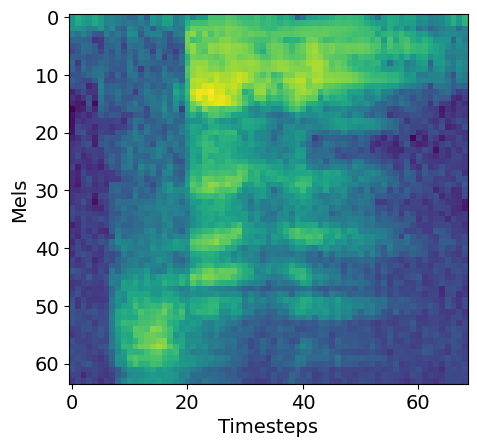

In [19]:
spectrogram = LogMelSpectrogram(sample_rate=16000, n_mels=64)
logmel_spec = spectrogram(resampled_waveform.squeeze())
print(f'Spectrogram shape: {logmel_spec.shape}')
print(f'Values range: ({logmel_spec.min(), logmel_spec.max()})')

plt.imshow(logmel_spec.numpy())
plt.ylabel('Mels')
plt.xlabel('Timesteps')
plt.show()

## Task 0. Preparation

**0 points**

* Let’s discuss how to split the data into train and test. Since we want to experiment with voice biometrics, it makes sense to split the data by speakers. Set aside one third of the speakers as the test set. The remaining speakers will serve as train and validation. Split them in an 80:20 ratio. This time you don’t need to split the data by speakers; instead, perform a stratified split (both by speakers and by classes within speakers).

* In this assignment, we will work with two representations of audio data: raw audio waveforms and log mel-spectrograms. We will process them using 1D and 2D convolutions, respectively. Implement two small neural networks: one with a 1D encoder and one with a 2D encoder. It will be sufficient to stack several convolutional layers, since our data is quite simple and does not require SOTA architectures. We recommend using 1D convolutions with dilation, stride, and a relatively large kernel size.

In [ ]:
import sys
import json
import torch

import os
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sys.path.append('.')

from config.config import Config
from datasets import get_speaker_splits, get_dataloaders, AudioMNISTDataset
from models import Encoder1D, Encoder2D, SupervisedModel1D, SupervisedModel2D

train_speakers, val_speakers, test_speakers = get_speaker_splits()
print(f"Train speakers: {len(train_speakers)} - {train_speakers[:5]}...")
print(f"Val speakers: {len(val_speakers)} - {val_speakers}")
print(f"Test speakers: {len(test_speakers)} - {test_speakers[:5]}...")

train_loader, val_loader, test_loader = get_dataloaders(batch_size=32)
print(f"\nDataset sizes:")
print(f"  Train: {len(train_loader.dataset)} samples")
print(f"  Val: {len(val_loader.dataset)} samples")
print(f"  Test: {len(test_loader.dataset)} samples")

Train speakers: 32 - ['60', '27', '46', '30', '34']...
Val speakers: 8 - ['40', '37', '36', '47', '25', '33', '58', '48']
Test speakers: 20 - ['01', '02', '03', '04', '05']...

Dataset sizes:
  Train: 12800 samples
  Val: 4000 samples
  Test: 10000 samples


In [ ]:
encoder_1d = Encoder1D()
x_wave = torch.randn(4, 1, 16000)
out_1d = encoder_1d(x_wave)
print("1D Encoder (Raw Waveforms):")
print(f"  Input shape: {x_wave.shape}")
print(f"  Output shape: {out_1d.shape}")
print(f"  Parameters: {sum(p.numel() for p in encoder_1d.parameters()):,}")
print(encoder_1d)

encoder_2d = Encoder2D()
x_spec = torch.randn(4, 1, 64, 100)
out_2d = encoder_2d(x_spec)
print("\n2D Encoder (Spectrograms):")
print(f"  Input shape: {x_spec.shape}")
print(f"  Output shape: {out_2d.shape}")
print(f"  Parameters: {sum(p.numel() for p in encoder_2d.parameters()):,}")
print(encoder_2d)

1D Encoder (Raw Waveforms):
  Input shape: torch.Size([4, 1, 16000])
  Output shape: torch.Size([4, 256])
  Parameters: 712,832
Encoder1D(
  (encoder): Sequential(
    (0): ConvBlock1D(
      (conv): Conv1d(1, 32, kernel_size=(15,), stride=(4,), padding=(14,), dilation=(2,))
      (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): ConvBlock1D(
      (conv): Conv1d(32, 64, kernel_size=(15,), stride=(4,), padding=(14,), dilation=(2,))
      (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (2): ConvBlock1D(
      (conv): Conv1d(64, 128, kernel_size=(15,), stride=(4,), padding=(7,))
      (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (3): ConvBlock1D(
      (conv): Conv1d(128, 256, kernel_size=(15,), stride=(4,), padding=(7,))
      (bn): BatchNor

## Task 1. Supervised Models

**1 point**

Independently train the 1D encoder on raw waveforms and the 2D encoder on log mel-spectrograms for digit classification. Use accuracy as the evaluation metric. Assess the performance on the test set.

In [ ]:
from scripts.train_supervised import train_supervised_1d, train_supervised_2d

print(f"Device: {Config.DEVICE}")

model_1d, acc_1d = train_supervised_1d()

model_2d, acc_2d = train_supervised_2d()

print("\n" + "="*60)
print("Task 1 Results: Supervised Training")
print("="*60)
print(f"1D Model (Waveforms) Test Accuracy: {acc_1d:.2f}%")
print(f"2D Model (Spectrograms) Test Accuracy: {acc_2d:.2f}%")

Device: mps

Training Supervised 1D Model (Waveforms)


[supervised_1d] epoch: 10, train_loss: 0.0282, train_acc: 99.1562, val_loss: 29.0214, val_acc: 12.1000


[supervised_1d] epoch: 20, train_loss: 0.0052, train_acc: 99.8516, val_loss: 34.6128, val_acc: 23.6500


[supervised_1d] epoch: 30, train_loss: 0.0008, train_acc: 100.0000, val_loss: 8.9760, val_acc: 53.0500


[supervised_1d] epoch: 40, train_loss: 0.0002, train_acc: 100.0000, val_loss: 11.4643, val_acc: 31.8000


...

[supervised_2d] epoch: 20, train_loss: 0.0000, train_acc: 100.0000, val_loss: 0.0069, val_acc: 99.8250


[supervised_2d] epoch: 30, train_loss: 0.0000, train_acc: 100.0000, val_loss: 0.0079, val_acc: 99.8250


[supervised_2d] epoch: 40, train_loss: 0.0000, train_acc: 100.0000, val_loss: 0.0068, val_acc: 99.8500


[supervised_2d] epoch: 50, train_loss: 0.0000, train_acc: 100.0000, val_loss: 0.0075, val_acc: 99.8500



Test Accuracy (2D): 99.70%
Logs saved to ./results/supervised_2d_20251204_021719.json

Task 1 Results: Supervised Training
1D Model (Waveforms) Test Accuracy: 96.58%
2D Model (Spectrograms) Test Accuracy: 99.70%


## Task 2. Multi-format contrastive learning

**4 points**

Now let's move to unsupervised pretraining. You need to implement a method that contrasts embeddings from two formats of audio data: [paper](https://arxiv.org/abs/2103.06508). Use the same encoder architectures as in the supervised training. We recommend checking the discussion of the second homework to correctly implement the contrastive loss.

Choose one type of augmentation for the raw audio waveforms and one for the spectrograms, and train 4 different models (no augmentations, augmentation only for waveforms, augmentation only for spectrograms, and augmentation for both). Measure linear probe performance in three ways (only on the 1D encoder outputs, only on the 2D encoder outputs, and on the concatenation of outputs) and select the best model by validation. That model will be used in subsequent experiments. Evaluate performance on the test set.

To save time, we will not fine-tune the models and will limit ourselves to linear probing only.

In [ ]:
from scripts.train_contrastive import train_all_contrastive_models

contrastive_models = train_all_contrastive_models()


Training Contrastive Model: contrastive_no_aug
Waveform Augmentation: False
Spectrogram Augmentation: False


[contrastive_no_aug] epoch: 10, train_loss: 0.2411, val_loss: 8.0387


[contrastive_no_aug] epoch: 20, train_loss: 0.1006, val_loss: 6.0772


[contrastive_no_aug] epoch: 30, train_loss: 0.0548, val_loss: 6.3281


[contrastive_no_aug] epoch: 40, train_loss: 0.0500, val_loss: 5.4320


...

[contrastive_wav_aug_spec_aug] epoch: 60, train_loss: 0.1505, val_loss: 1.2417


[contrastive_wav_aug_spec_aug] epoch: 70, train_loss: 0.1237, val_loss: 1.1262


[contrastive_wav_aug_spec_aug] epoch: 80, train_loss: 0.1119, val_loss: 1.1729


[contrastive_wav_aug_spec_aug] epoch: 90, train_loss: 0.0948, val_loss: 0.9783


[contrastive_wav_aug_spec_aug] epoch: 100, train_loss: 0.0980, val_loss: 0.9684
Logs saved to ./results/contrastive_wav_aug_spec_aug_20251204_043716.json

Best validation loss: 0.9662


In [ ]:
from scripts.linear_probe import main as run_linear_probe

run_linear_probe()

with open('results/linear_probe_results.json', 'r') as f:
    linear_probe_results = json.load(f)

print("\nLinear Probe Results Summary:")
print("="*80)
print(f"{'Model':<40} {'1D Acc':<12} {'2D Acc':<12} {'Concat Acc':<12}")
print("-"*80)
for model_name, results in linear_probe_results.items():
    print(f"{model_name:<40} {results['1d']['test_acc']:.2f}%      {results['2d']['test_acc']:.2f}%      {results['concat']['test_acc']:.2f}%")


Linear Probing: contrastive_no_aug

Probe type: 1d


  Epoch 10: Train Acc: 52.47%, Val Acc: 55.83%


  Epoch 20: Train Acc: 55.40%, Val Acc: 56.67%


  Epoch 30: Train Acc: 57.18%, Val Acc: 58.02%


  Epoch 40: Train Acc: 58.08%, Val Acc: 57.77%


...

  Epoch 10: Train Acc: 88.17%, Val Acc: 85.28%


  Epoch 20: Train Acc: 90.97%, Val Acc: 88.55%


  Epoch 30: Train Acc: 92.37%, Val Acc: 90.28%


  Epoch 40: Train Acc: 93.00%, Val Acc: 90.88%


  Epoch 50: Train Acc: 93.26%, Val Acc: 90.58%
  Best Val Acc: 90.88%, Test Acc: 85.61%

Linear Probing Summary

Model                               1D           2D           Concat      
---------------------------------------------------------------------------
contrastive_no_aug                  54.43%      59.92%      65.63%
contrastive_wav_aug                 63.48%      73.91%      74.71%
contrastive_spec_aug                76.11%      76.32%      81.23%
contrastive_wav_aug_spec_aug        66.92%      86.20%      85.61%

Linear Probe Results Summary:
Model                                    1D Acc       2D Acc       Concat Acc  
--------------------------------------------------------------------------------
contrastive_no_aug                       54.43%      59.92%      65.63%
contrastive_wav_aug                      63.48%      73.91%      74.71%
contrastive_spec_aug                     76.11%      76.32%      81.23%
contrastive_wav_aug_spec_aug             66.92%      86.20% 

## Task 3. Visualization

**2 points**

We now have 4 models: two 1D encoders and two 2D encoders trained in supervised and self-supervised manner. For each of the 4 models, plot a t-SNE of the embeddings for the test set (the test split you set aside at the beginning of the assignment). For each model produce two plots: one where embeddings are colored by speaker (each speaker a different color) and another where embeddings are colored by digit.

Device: mps

Visualizing Supervised Models
Loaded supervised 1D model
Loaded supervised 2D model
Extracting embeddings from supervised 1D model...


Extracting embeddings from supervised 2D model...



Visualizing Contrastive Models
Loaded contrastive_no_aug
Extracting embeddings from contrastive_no_aug...


Loaded contrastive_wav_aug
Extracting embeddings from contrastive_wav_aug...


Loaded contrastive_spec_aug
Extracting embeddings from contrastive_spec_aug...


Loaded contrastive_wav_aug_spec_aug
Extracting embeddings from contrastive_wav_aug_spec_aug...



Creating t-SNE Plots

Computing t-SNE for supervised_1d...

Computing t-SNE for supervised_2d...

Computing t-SNE for contrastive_no_aug_1d...

Computing t-SNE for contrastive_no_aug_2d...

Computing t-SNE for contrastive_wav_aug_1d...

Computing t-SNE for contrastive_wav_aug_2d...

Computing t-SNE for contrastive_spec_aug_1d...

Computing t-SNE for contrastive_spec_aug_2d...

Computing t-SNE for contrastive_wav_aug_spec_aug_1d...

Computing t-SNE for contrastive_wav_aug_spec_aug_2d...

Plots saved to ./results/tsne_plots


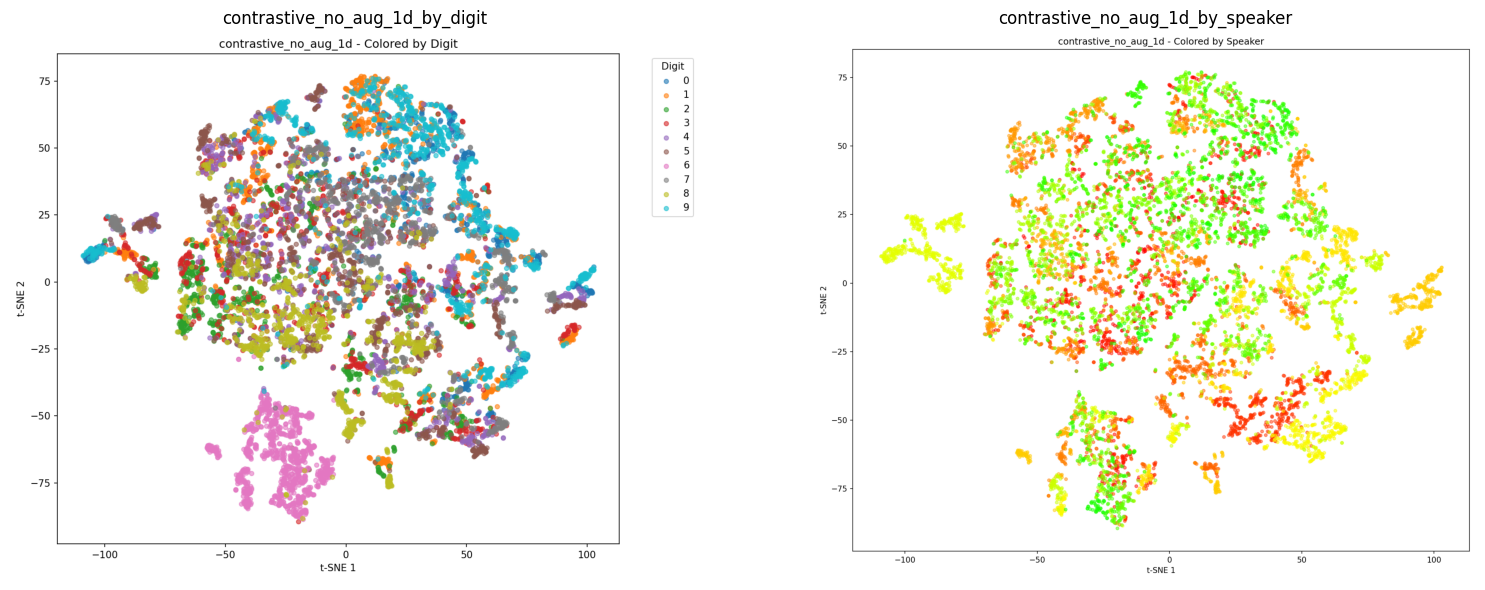

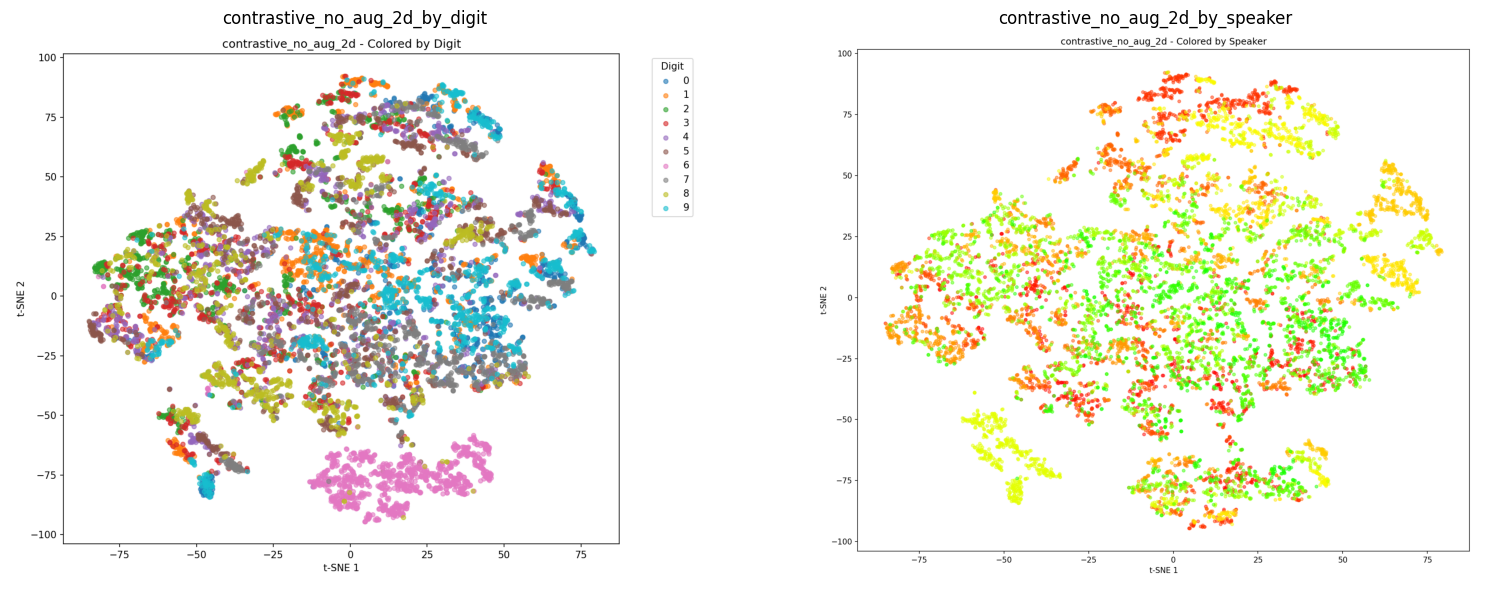

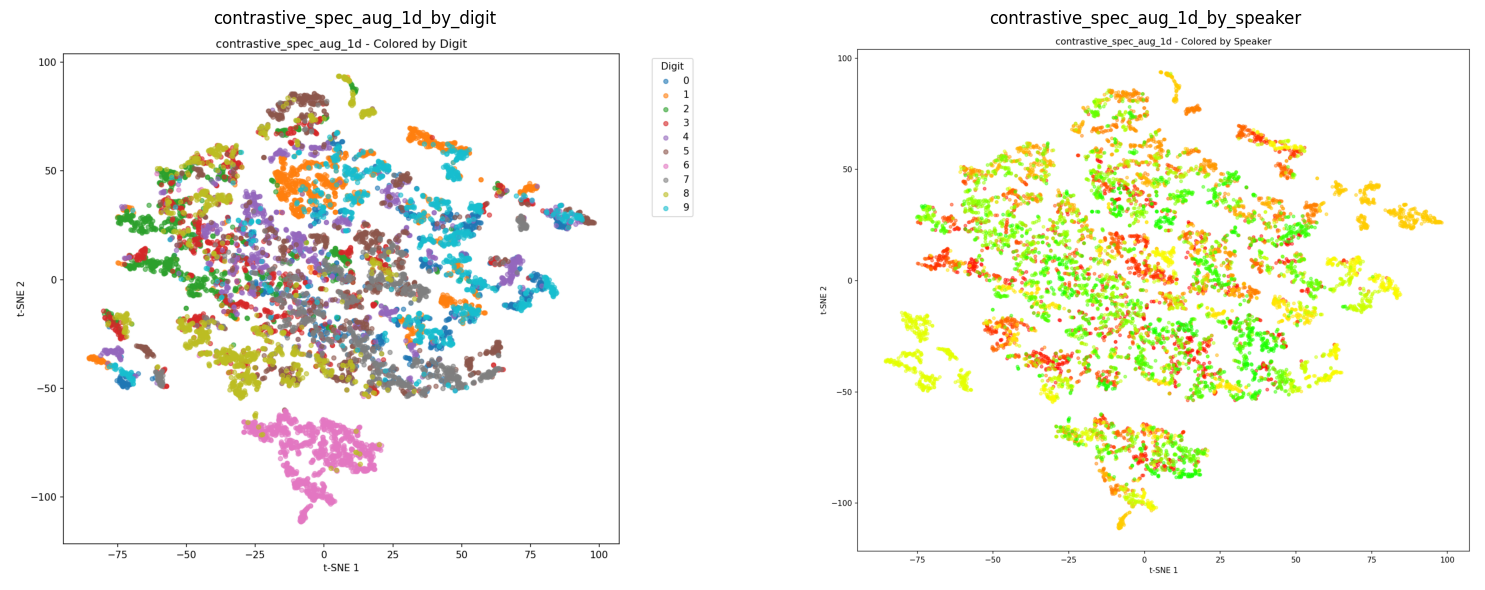

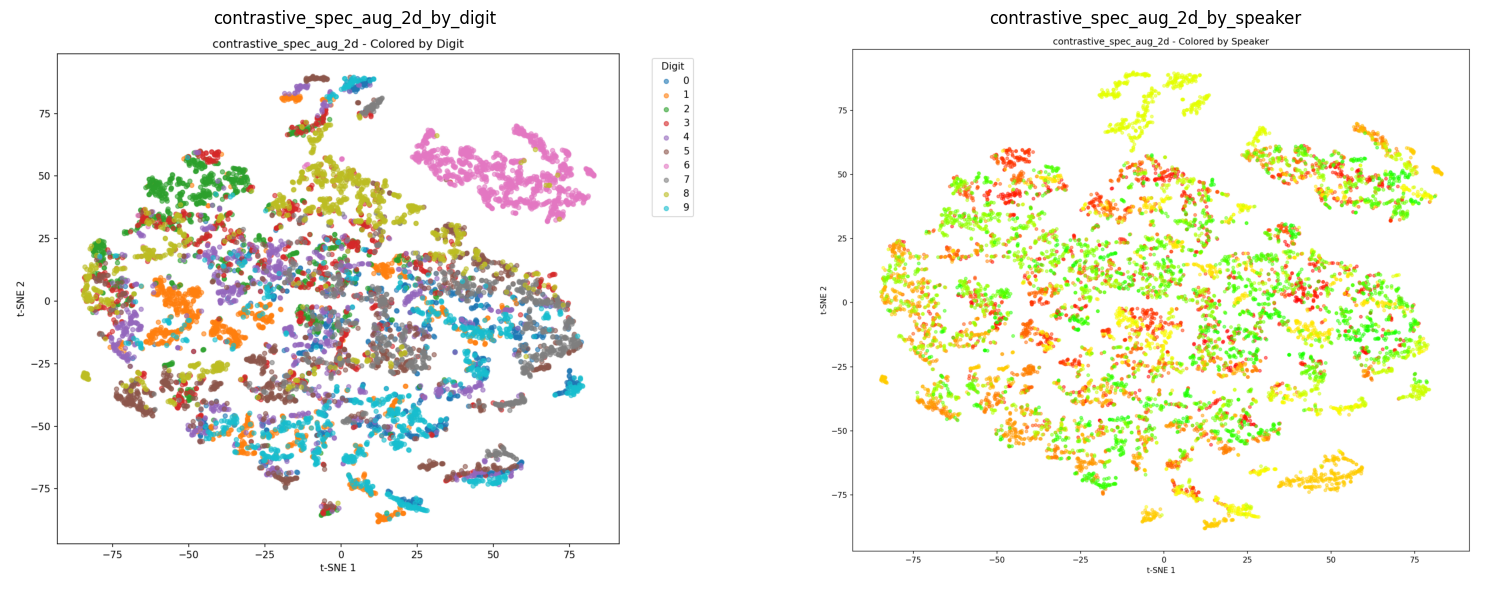

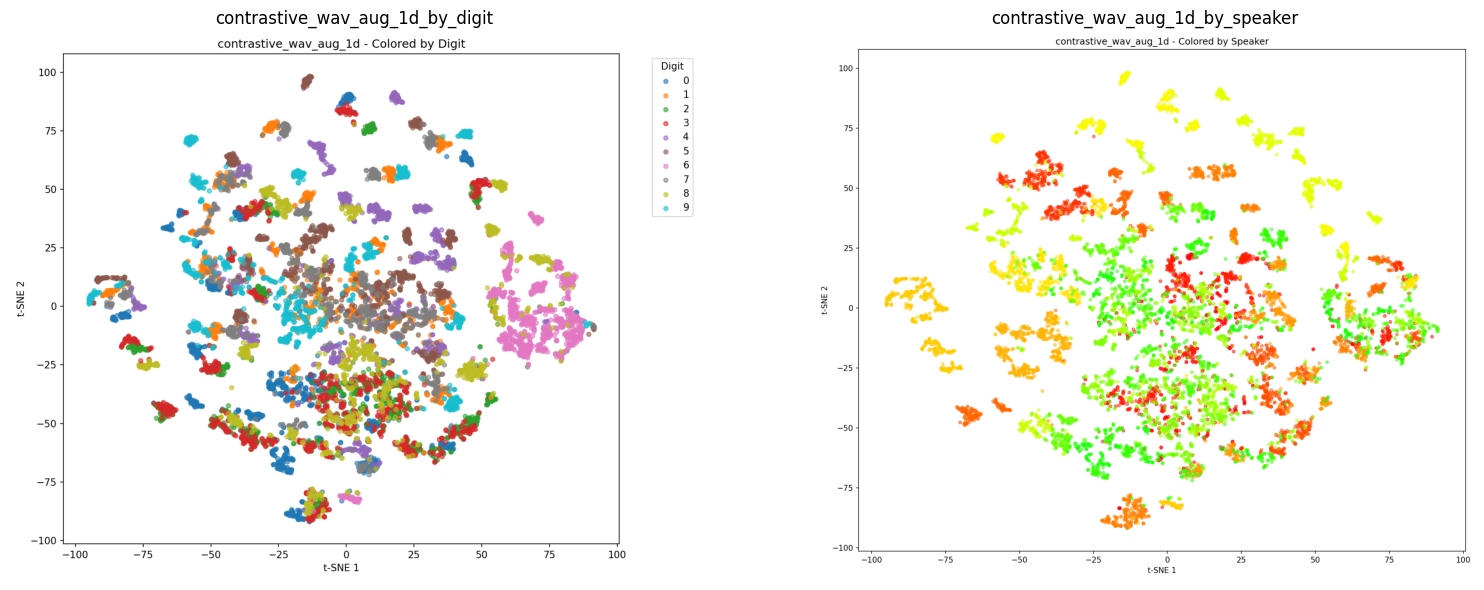

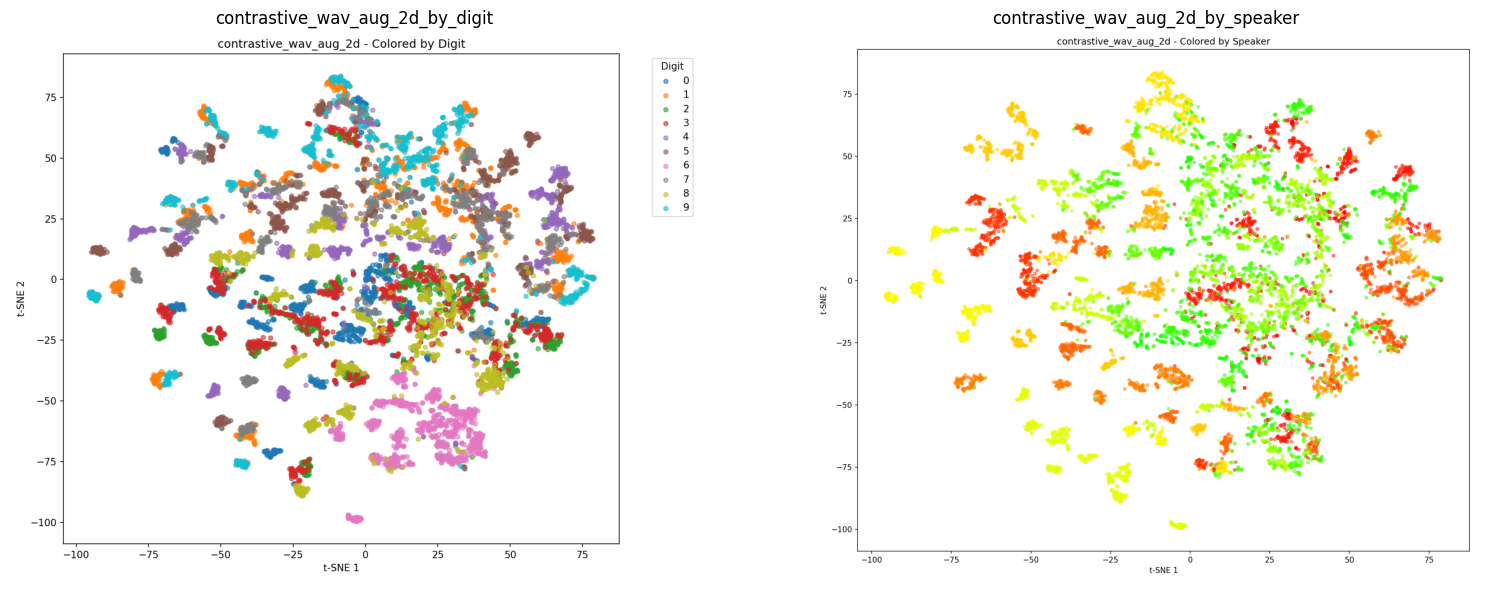

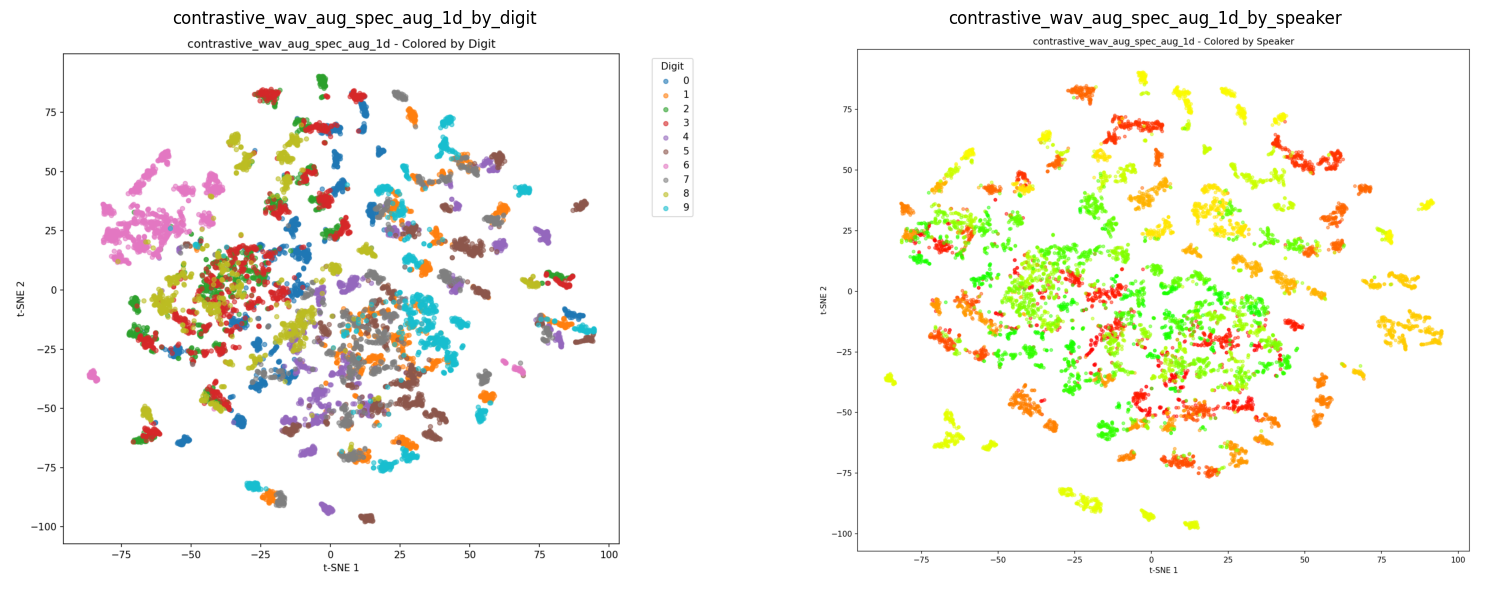

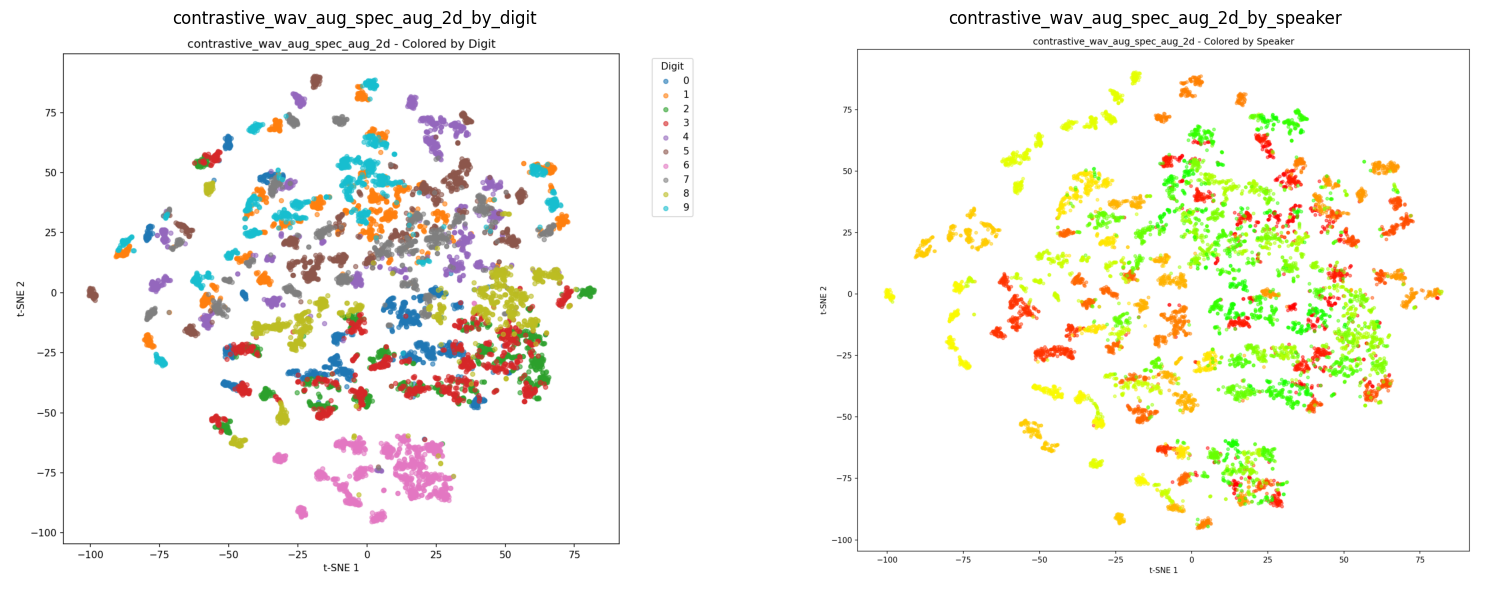

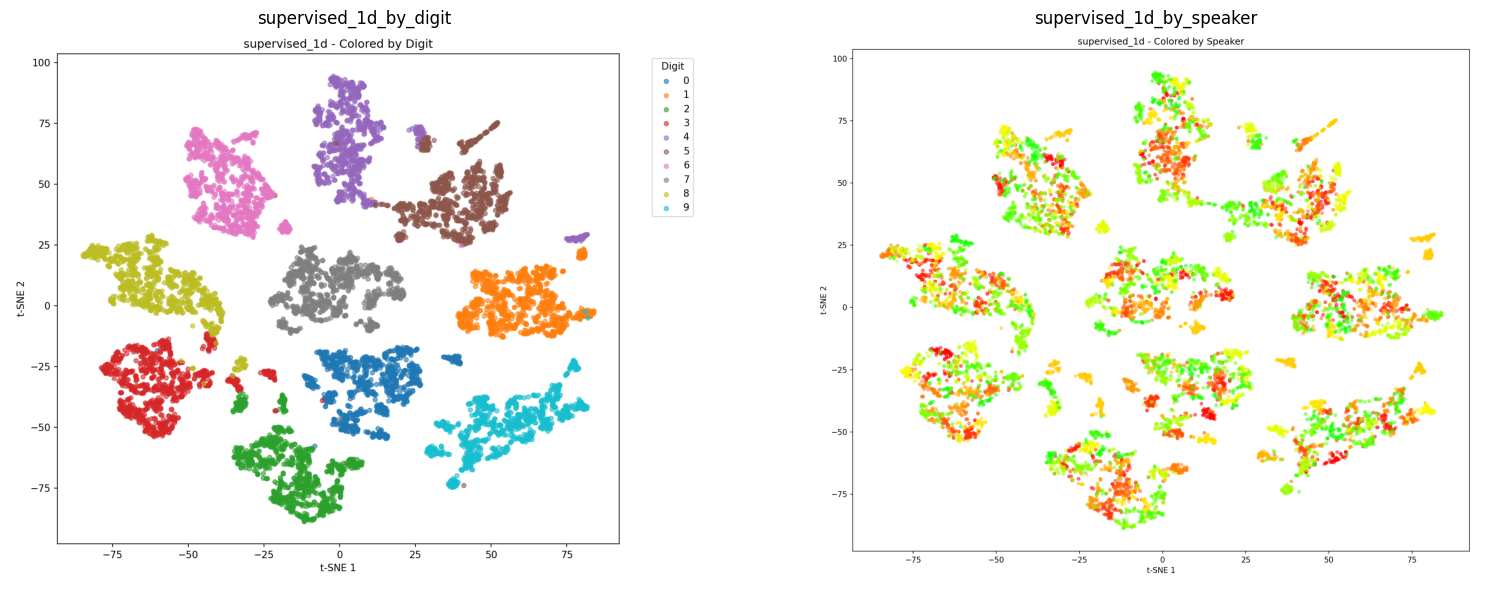

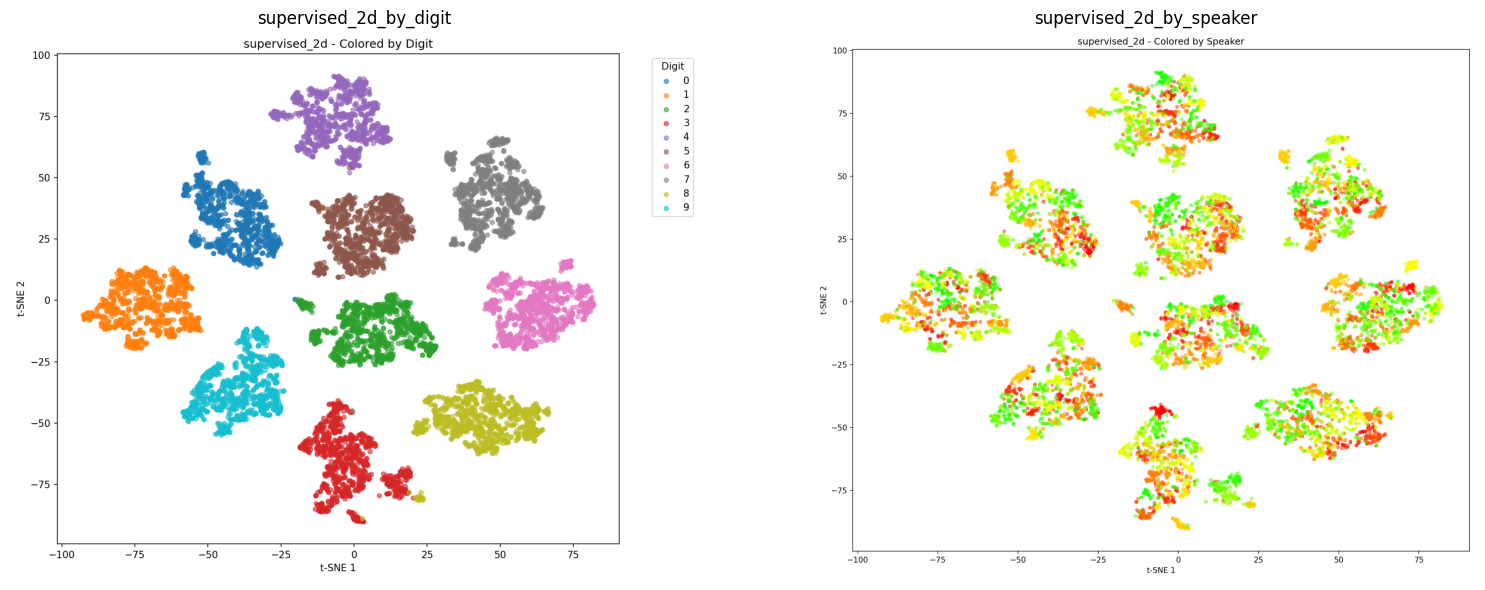

In [ ]:
from scripts.visualize import main as run_visualization

run_visualization()

plot_dir = 'results/tsne_plots'
if os.path.exists(plot_dir):
    plot_files = sorted([f for f in os.listdir(plot_dir) if f.endswith('.png')])
    
    for i in range(0, len(plot_files), 2):
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        for j, ax in enumerate(axes):
            if i + j < len(plot_files):
                img = mpimg.imread(os.path.join(plot_dir, plot_files[i + j]))
                ax.imshow(img)
                ax.axis('off')
                ax.set_title(plot_files[i + j].replace('.png', ''))
        
        plt.tight_layout()
        plt.show()
else:
    print("No plots found. Run visualization first.")

## Task 4. Voice Biometrics

**3 points**

Since a model for voice biometrics must be able to handle new speakers, non-parametric classifiers such as kNN are very often used for this task.

We will evaluate voice biometrics as follows: take the test speakers and generate embeddings of their recordings using the model. Then split these embeddings into two equal-sized subsets: we will train kNN on one subset and test it on the other. As with the train/validation split, you must perform a stratified split both by speakers and by digits.

Select the optimal number of neighbors **k** via cross-validation on the training subset (i.e., the subset taken from the test set, not the original training data), and compute the speaker classification accuracy for all 4 models.

In [ ]:
from scripts.voice_biometrics import main as run_voice_biometrics

run_voice_biometrics()

with open('results/voice_biometrics_results.json', 'r') as f:
    biometrics_results = json.load(f)

print("\nVoice Biometrics Results (Speaker Classification):")
print("="*70)
print(f"{'Model':<45} {'Best k':<10} {'Test Acc':<12}")
print("-"*70)
for model_name, res in biometrics_results.items():
    print(f"{model_name:<45} {res['best_k']:<10} {res['test_accuracy']:.2f}%")

Device: mps

Evaluating Supervised 1D Model
  Cross-validating k...
  Best k: 5, CV Score: 71.00%
  Test Accuracy: 73.78%

Evaluating Supervised 2D Model
  Cross-validating k...
  Best k: 5, CV Score: 67.40%
  Test Accuracy: 68.66%

Evaluating contrastive_no_aug
  1D Encoder:
  Cross-validating k...
  Best k: 11, CV Score: 66.54%
    Test Accuracy: 69.14%
  2D Encoder:
  Cross-validating k...
  Best k: 5, CV Score: 64.98%
    Test Accuracy: 66.12%
  Concatenated:
  Cross-validating k...
  Best k: 7, CV Score: 66.88%
    Test Accuracy: 68.76%

Evaluating contrastive_wav_aug
  1D Encoder:
  Cross-validating k...
  Best k: 1, CV Score: 83.80%
    Test Accuracy: 85.16%
  2D Encoder:
  Cross-validating k...
  Best k: 1, CV Score: 84.44%
    Test Accuracy: 86.88%
  Concatenated:
  Cross-validating k...
  Best k: 1, CV Score: 86.54%
    Test Accuracy: 88.50%

Evaluating contrastive_spec_aug
  1D Encoder:
  Cross-validating k...
  Best k: 5, CV Score: 63.12%
    Test Accuracy: 64.88%
  2D Enco

## Task 5. Bonus

**1 point**

Fine-tune the self-supervised models on digit classification. Compare the classification and voice-biometrics performance with the supervised models and with the linear-probe results

In [3]:
from scripts.finetune import main as run_finetune

run_finetune()

print("\n" + "="*80)
print("FINAL COMPARISON: Digit Classification Accuracy")
print("="*80)

supervised_1d = json.load(open('results/supervised_1d_metrics.json'))
supervised_2d = json.load(open('results/supervised_2d_metrics.json'))
linear_probe = json.load(open('results/linear_probe_results.json'))
finetune = json.load(open('results/finetune_results.json'))

print(f"\n{'Method':<50} {'Test Accuracy':<15}")
print("-"*65)
print(f"{'Supervised 1D':<50} {supervised_1d['test_acc']:.2f}%")
print(f"{'Supervised 2D':<50} {supervised_2d['test_acc']:.2f}%")
print()

best_model = max(linear_probe.items(), key=lambda x: x[1]['concat']['val_acc'])
print(f"Best SSL Model: {best_model[0]}")
print(f"  Linear Probe 1D: {best_model[1]['1d']['test_acc']:.2f}%")
print(f"  Linear Probe 2D: {best_model[1]['2d']['test_acc']:.2f}%")
print(f"  Linear Probe Concat: {best_model[1]['concat']['test_acc']:.2f}%")

print("\nFine-tuned Models:")
for model_name, res in finetune.items():
    print(f"  {model_name}: {res['test_acc']:.2f}%")


Device: mps

Fine-tuning: contrastive_no_aug

Fine-tuning contrastive_no_aug (1d encoder)


  Epoch 10: Train Acc: 66.77%, Val Acc: 63.50%


  Epoch 20: Train Acc: 72.83%, Val Acc: 71.35%


  Epoch 30: Train Acc: 74.12%, Val Acc: 72.88%


  Test Accuracy: 68.93%

Fine-tuning contrastive_no_aug (2d encoder)


...

  Test Accuracy: 69.75%

Fine-tuning contrastive_wav_aug_spec_aug (2d encoder)


  Epoch 10: Train Acc: 93.30%, Val Acc: 94.38%


  Epoch 20: Train Acc: 97.13%, Val Acc: 97.33%


  Epoch 30: Train Acc: 97.47%, Val Acc: 97.35%


  Test Accuracy: 93.42%

Fine-tuning Summary (Digit Classification)

Model                                         Val Acc      Test Acc    
----------------------------------------------------------------------
contrastive_no_aug_1d_finetuned               73.58%      68.93%
contrastive_no_aug_2d_finetuned               87.50%      83.21%
contrastive_wav_aug_1d_finetuned              66.33%      64.93%
contrastive_wav_aug_2d_finetuned              93.83%      88.04%
contrastive_spec_aug_1d_finetuned             88.30%      79.48%
contrastive_spec_aug_2d_finetuned             96.17%      92.12%
contrastive_wav_aug_spec_aug_1d_finetuned     71.75%      69.75%
contrastive_wav_aug_spec_aug_2d_finetuned     97.53%      93.42%

Results saved to ./results/finetune_results.json

Voice Biometrics Evaluation (Fine-tuned Models)

contrastive_no_aug_1d_finetuned:
  Cross-validating k...
  Best k: 9, CV Score: 64.66%
  Speaker Classification Accuracy: 66.98%

contrastive_no_aug_2d_finetuned:
  Cro